# 04. PyTorch Custom Datasets

We've used some datasets with PyTorch before.

But how do you get your own data into PyTorch?

One of the ways to do so is via: custom datasets.

## Domain libraries

Depending on what you're working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch domain libraries for existing data laoding functions and customizable data laoding functions.


## 0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn


In [2]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

## 1. Get data

Our dataset is a subset of the Food101 dataset.
Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

Our dataset starts with 3 classes of fodd and only 10% of thew images (round 75 training, 25 testing).

Why do this?

When starting out ML projects, it's important to try things on a small scale and then increase the scale when necessary.

The whole point is to speed up how fast you can experiment.

In [3]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path =Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory already exists...skipping download")

else:
    print(f"{image_path} does not exist, create one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak, and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    requests = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
    f.write(requests.content)

# Unzip pizza, steak, and sushi data
with zipfile.ZipFile(data_path/ "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, and sushi data...")
    zip_ref.extractall(image_path)

data\pizza_steak_sushi directory already exists...skipping download
Unzipping pizza, steak, and sushi data...


## 2. Becoming one with the data (data preparation and data exploration)

In [7]:
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning its contens."""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.") 

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [6]:
# Sepup train and test path
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir


(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and image

Let's write some code to:
1. Get all of the image paths
2. Pick a random image path using Python's random.choise()
3. Get the image class name using 'pathlib.Path.parent'
4. Sine we're working with images, let's open the image with Python's PIL
5. We'll then show the image and print metadata

Random image path: data\pizza_steak_sushi\train\pizza\2785084.jpg
Image class: pizza
Image heigh: 366
Image width: 512


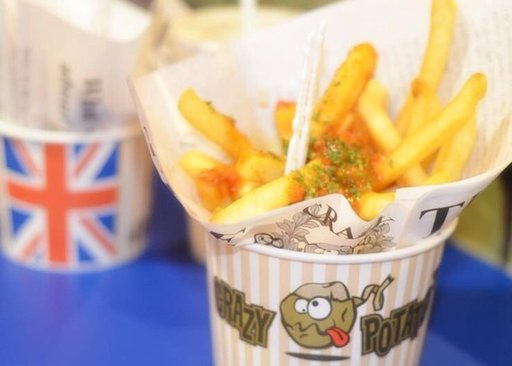

In [7]:
import random
from PIL import Image

# Set seed
# random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

image_path_list

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)


# 3. Get image class from path name (the image class is the name of the directory where the image is store)
image_class = random_image_path.parent.stem


# 4. Open image 
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: { random_image_path}")
print(f"Image class: {image_class}")
print(f"Image heigh: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(365.5), np.float64(-0.5))

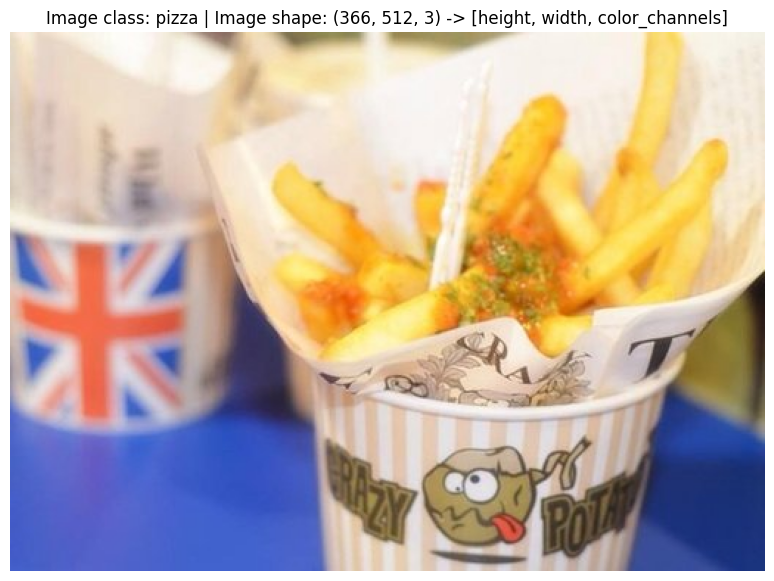

In [8]:
# Try to visualize and image with matplotlib...
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

#Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels] (HWC)")
plt.axis(False)

## 3. Transforming data

Before we can use our image data with PyTorch:
1. Turn your target data into tensors (in our case, numerical representation of our images).
2. Turn it into a 'torch.utils.data.Dataset' and subsequenly a 'torch.utils.data.DataLoader', we'll call these 'dataset' and 'dataloader'.


In [22]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## 3.1 Transforming data with torchvision.transforms

Transforms help you to get your images ready to be used with a model/perform data augmentation

In [23]:
# Write a transforms for image
data_transform = transforms.Compose([
    #Resize our image to 64x64
    transforms.Resize(size=(64, 64)),
    #Flip the images randomly
    transforms.RandomHorizontalFlip(p=0.5),
    #Turn the image into a torch.tensor
    transforms.ToTensor()
])

In [11]:
data_transform(img_as_array)

TypeError: Unexpected type <class 'numpy.ndarray'>

In [12]:
data_transform(img)

tensor([[[0.9569, 0.9608, 0.9686,  ..., 0.9255, 0.9686, 0.9490],
         [0.9529, 0.9608, 0.9647,  ..., 0.9216, 0.9608, 0.9294],
         [0.9490, 0.9529, 0.9529,  ..., 0.9216, 0.9490, 0.9216],
         ...,
         [0.1098, 0.1059, 0.1020,  ..., 0.2863, 0.2745, 0.2667],
         [0.1059, 0.1020, 0.0980,  ..., 0.2863, 0.2706, 0.2627],
         [0.1020, 0.0980, 0.1020,  ..., 0.2824, 0.2706, 0.2667]],

        [[0.9451, 0.9490, 0.9529,  ..., 0.8627, 0.9176, 0.8941],
         [0.9294, 0.9373, 0.9451,  ..., 0.8549, 0.9059, 0.8745],
         [0.9176, 0.9216, 0.9333,  ..., 0.8510, 0.8863, 0.8627],
         ...,
         [0.1961, 0.1961, 0.1961,  ..., 0.3765, 0.3725, 0.3608],
         [0.2039, 0.2000, 0.1961,  ..., 0.3765, 0.3686, 0.3647],
         [0.2039, 0.2000, 0.2000,  ..., 0.3765, 0.3765, 0.3725]],

        [[0.8980, 0.9020, 0.9098,  ..., 0.7922, 0.8431, 0.8157],
         [0.8824, 0.8941, 0.9020,  ..., 0.7922, 0.8078, 0.7804],
         [0.8706, 0.8745, 0.8902,  ..., 0.7961, 0.7882, 0.

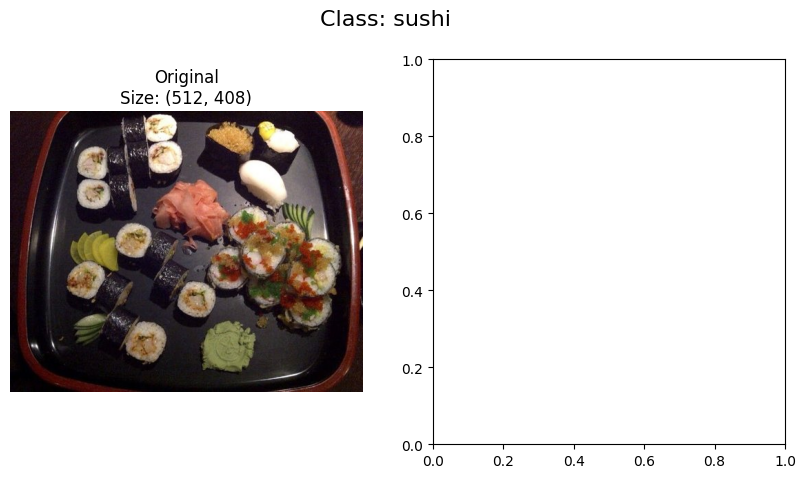

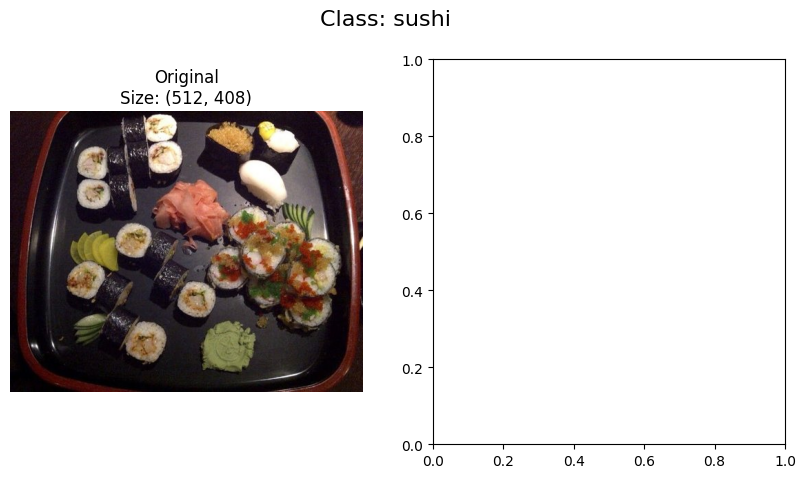

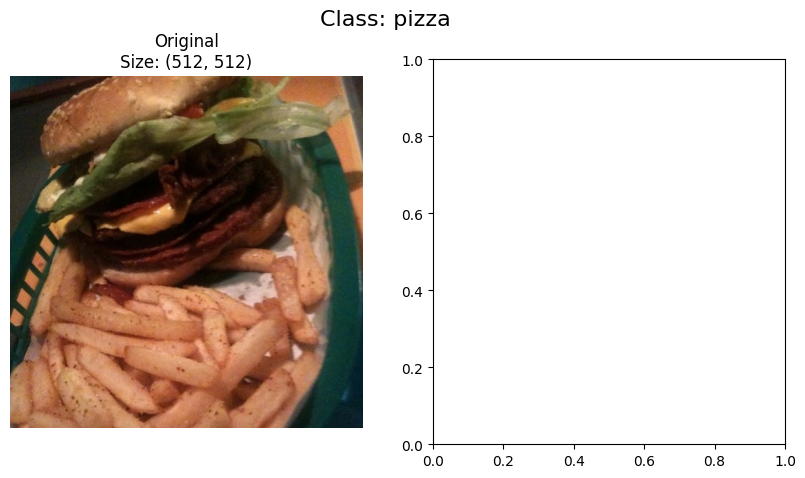

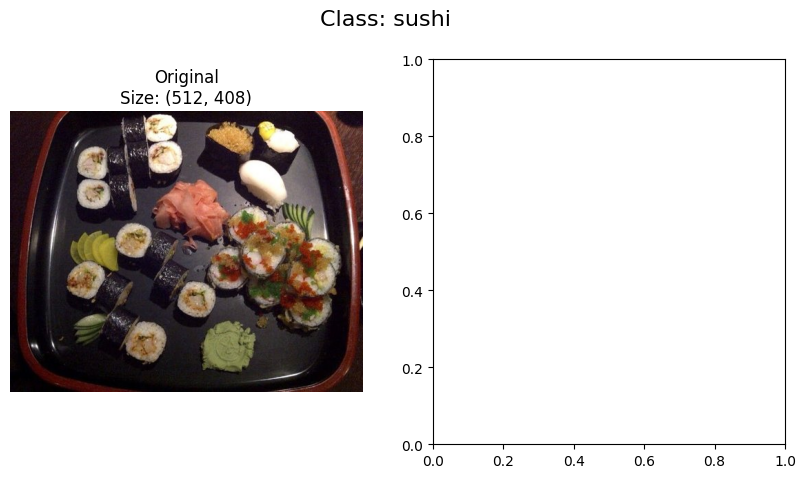

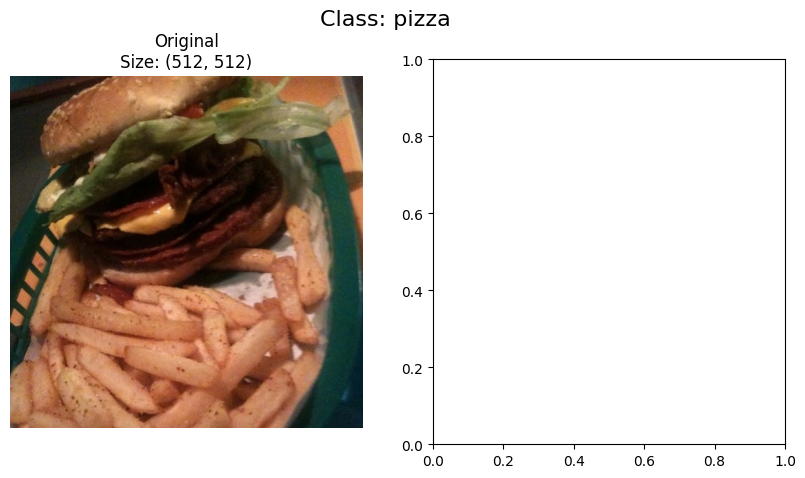

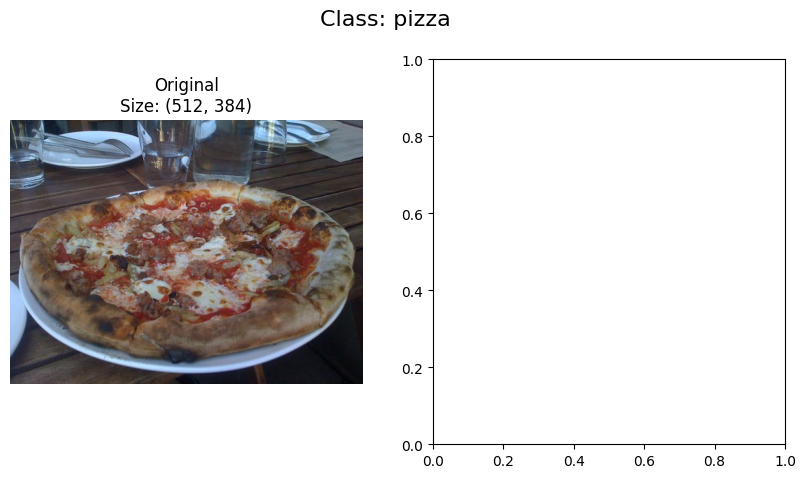

In [27]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
    """
    Selects random images from a path of images and loads/transforms
    them then plots the original vs the transformed version.
    """

    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            # create side-by-side subplots
            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

            # original image (PIL Image)
            axes[0].imshow(f)
            axes[0].set_title(f"Original\nSize: {f.size}")
            axes[0].axis('off')

            # Transform and plot target image
            transformed_image = transform(f).permute(1, 2, 0) # we will need to change shape for matplotlib
            axes[1].imshow(transformed_image)
            axes[1].set_title(f"Transfromed\nShape: {transformed_image.shape}")
            axes[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)

In [78]:
class TinyVGG(nn.Module):
    """
    Model architechture copying TinyVGG from CNN Explainer
    """

    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
                            nn.Conv2d(in_channels=input_shape,
                                        out_channels=hidden_units,
                                        kernel_size=3,
                                        stride=1,
                                        padding=0),
                            nn.ReLU(),
                            nn.Conv2d(in_channels=hidden_units,
                                        out_channels=hidden_units,
                                        kernel_size=3,
                                        stride=1,
                                        padding=0),
                            nn.ReLU(),
                            nn.MaxPool2d(kernel_size=2,
                                        stride=2)   # default stride value is same as kernel_size
        )

        self.conv_block_2 = nn.Sequential(
                            nn.Conv2d(in_channels=hidden_units,
                                    out_channels=hidden_units,
                                    kernel_size=3,
                                    stride=1,
                                    padding=0),
                            nn.ReLU(),
                            nn.Conv2d(in_channels=hidden_units,
                                    out_channels=hidden_units,
                                    kernel_size=3,
                                    stride=1,
                                    padding=0),
                            nn.ReLU(),
                            nn.MaxPool2d(kernel_size=2,
                                        stride=2)   # default stride value is same as kernel_size
        )

        self.classifier_layer = nn.Sequential(
                                nn.Flatten(),
                                nn.Linear(in_features=hidden_units*13*13,
                                        out_features=output_shape)
                            )

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier_layer(x)
        return x
        #return self.classifier_layer(self.conv_block_2(self.conv_block_1(x))) # benefits from operator fustion

In [79]:
## 7.4 Use 'torchinfo' to get an idea of the shapes going through our model

from torchinfo import summary

# Use the correct input size matching your training data (64x64, not 224x224)
summary(model_0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## 7.5 Create train and test loops functions

* 'train_step()' - take in a model and dataloader and trains the model on the dataloader.
* 'test_step()' - takes in a model and dataloader and evaluates the model on the dataloader.

In [ ]:
# Create train_step()

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put the model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X) # output model logits

        # 2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate accuracy metric
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim =1)
        train_acc += (y_pred_class ==y).sum().item()/len(y_pred)